Importamos librerias 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import math
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import joblib
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

In [2]:

url = 'https://raw.githubusercontent.com/4GeeksAcademy/random-forest-project-tutorial/main/titanic_train.csv'

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
    names=columns
)


df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:


print(df.isnull().sum())

print(df['Outcome'].value_counts())
print(f'Porcentaje diabéticos: {df["Outcome"].mean()*100:.1f}%')

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Outcome
0    500
1    268
Name: count, dtype: int64
Porcentaje diabéticos: 34.9%


In [6]:
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_con_ceros] = df[cols_con_ceros].replace(0, np.nan)

for col in cols_con_ceros:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2824/2129570731.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2824/2129570731.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to u

In [ ]:

X = df.drop('Outcome', axis=1)
y = df['Outcome']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño entrenamiento: {X_train.shape}')
print(f'Tamaño prueba:        {X_test.shape}')

Tamaño entrenamiento: (614, 8)
Tamaño prueba:        (154, 8)


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy_base = accuracy_score(y_test, y_pred)

print(f' Accuracy del modelo base: {accuracy_base:.4f} ({accuracy_base*100:.2f}%)')

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

 Accuracy del modelo base: 0.7468 (74.68%)
              precision    recall  f1-score   support

 No Diabetes       0.79      0.84      0.81       100
    Diabetes       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



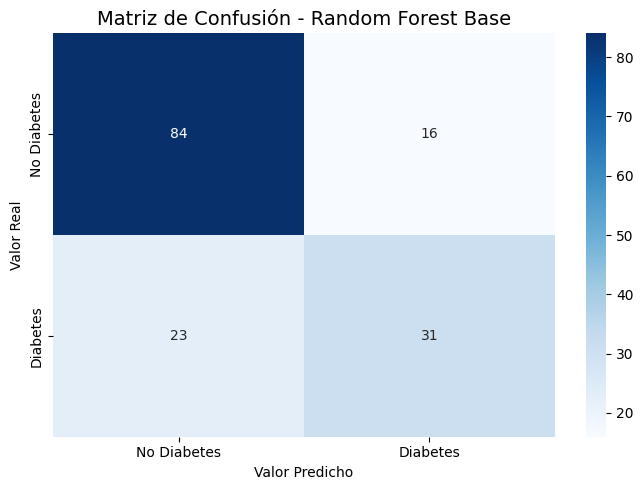

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Matriz de Confusión - Random Forest Base', fontsize=14)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

In [10]:
n_estimators_values = [5, 10, 25, 50, 100, 150, 200, 300]
accuracies_n = []

for n in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies_n.append(acc)
    print(f'  n_estimators={n:>4}  →  Accuracy: {acc:.4f}')

  n_estimators=   5  →  Accuracy: 0.7338
  n_estimators=  10  →  Accuracy: 0.7597
  n_estimators=  25  →  Accuracy: 0.7857
  n_estimators=  50  →  Accuracy: 0.7532
  n_estimators= 100  →  Accuracy: 0.7468
  n_estimators= 150  →  Accuracy: 0.7338
  n_estimators= 200  →  Accuracy: 0.7338
  n_estimators= 300  →  Accuracy: 0.7273


In [11]:
max_depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]
accuracies_d = []

for d in max_depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies_d.append(acc)
    label = str(d) if d is not None else 'None'
    print(f'  max_depth={label:>5}  →  Accuracy: {acc:.4f}')

  max_depth=    1  →  Accuracy: 0.7013
  max_depth=    2  →  Accuracy: 0.7273
  max_depth=    3  →  Accuracy: 0.7338
  max_depth=    5  →  Accuracy: 0.7273
  max_depth=    7  →  Accuracy: 0.7273
  max_depth=   10  →  Accuracy: 0.7532
  max_depth=   15  →  Accuracy: 0.7597
  max_depth=   20  →  Accuracy: 0.7468
  max_depth= None  →  Accuracy: 0.7468


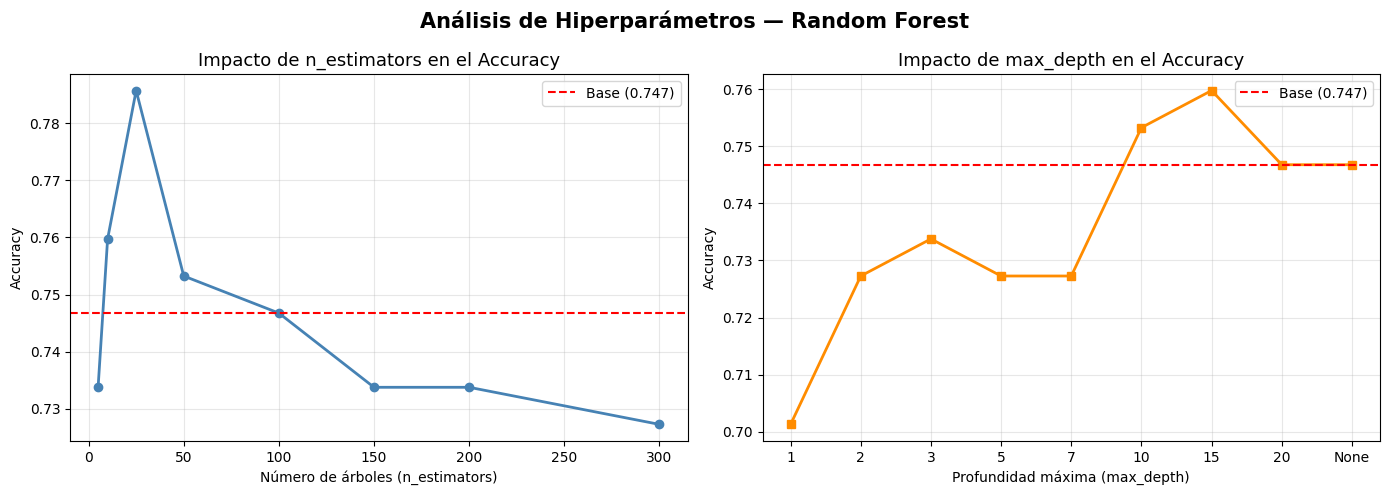

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(n_estimators_values, accuracies_n, marker='o', color='steelblue', linewidth=2)
axes[0].axhline(y=accuracy_base, color='red', linestyle='--', label=f'Base ({accuracy_base:.3f})')
axes[0].set_title('Impacto de n_estimators en el Accuracy', fontsize=13)
axes[0].set_xlabel('Número de árboles (n_estimators)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

depth_labels = [str(d) if d is not None else 'None' for d in max_depth_values]
axes[1].plot(range(len(max_depth_values)), accuracies_d, marker='s', color='darkorange', linewidth=2)
axes[1].axhline(y=accuracy_base, color='red', linestyle='--', label=f'Base ({accuracy_base:.3f})')
axes[1].set_title('Impacto de max_depth en el Accuracy', fontsize=13)
axes[1].set_xlabel('Profundidad máxima (max_depth)')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(len(max_depth_values)))
axes[1].set_xticklabels(depth_labels)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Hiperparámetros — Random Forest', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

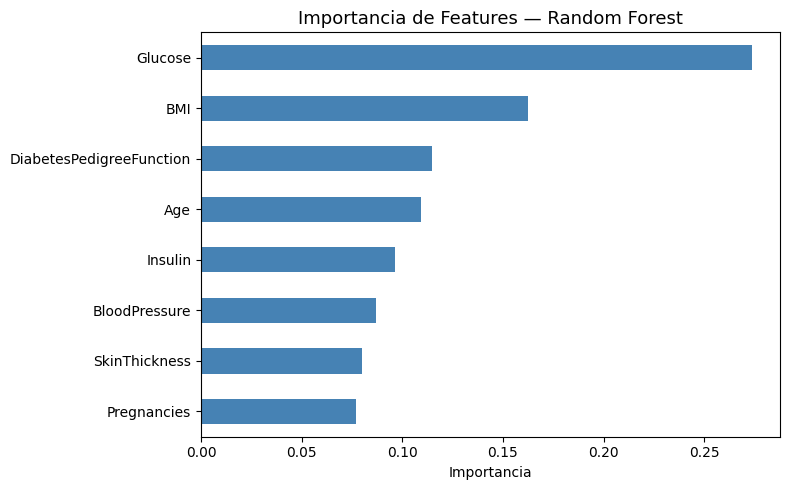


Top 3 features más importantes:
  Glucose: 0.2739
  BMI: 0.1624
  DiabetesPedigreeFunction: 0.1147


In [13]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importancia de Features — Random Forest', fontsize=13)
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('\nTop 3 features más importantes:')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {imp:.4f}')

In [14]:
best_n = n_estimators_values[np.argmax(accuracies_n)]
best_d = max_depth_values[np.argmax(accuracies_d)]

print(f'Mejor n_estimators: {best_n}')
print(f'Mejor max_depth:    {best_d}')

best_model = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_d,
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f'\n Accuracy modelo optimizado: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)')
print(f'   Mejora sobre modelo base:   +{(accuracy_best - accuracy_base)*100:.2f}%')

Mejor n_estimators: 25
Mejor max_depth:    15

 Accuracy modelo optimizado: 0.7857 (78.57%)
   Mejora sobre modelo base:   +3.90%


El análisis manual mostró que `n_estimators=25` y `max_depth=15` ofrecen el mejor accuracy individual (78.57%). Sin embargo, para encontrar la combinación óptima de múltiples hiperparámetros (incluyendo `class_weight` para el desbalanceo de clases), se aplica GridSearchCV a continuación.

In [ ]:


from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]  
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall'  
)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor recall (CV=5): {grid_search.best_score_:.4f}")

best_model_gs = grid_search.best_estimator_
y_pred_gs = best_model_gs.predict(X_test)
acc_gs = accuracy_score(y_test, y_pred_gs)

print(f"\nAccuracy modelo GridSearchCV: {acc_gs:.4f} ({acc_gs*100:.2f}%)")
print(classification_report(y_test, y_pred_gs, target_names=['No Diabetes', 'Diabetes']))


os.makedirs('../data/raw', exist_ok=True)
joblib.dump(best_model_gs, '../data/raw/random_forest_diabetes.pkl')


Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Mejor recall (CV=5): 0.7336

Accuracy modelo GridSearchCV: 0.7468 (74.68%)
              precision    recall  f1-score   support

 No Diabetes       0.84      0.75      0.79       100
    Diabetes       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154

Modelo guardado en ../data/raw/random_forest_diabetes.pkl
